# Exploratory Data Analysis (EDA)
### This notebook gives an understanding of the overall dataset, along with its structure and distributions that help guide further preprocessing and model building.

#### 1. Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#### 2. Import dataframes

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

MOVIES_DATA_PATH = DATA_DIR / "movies.csv"
RATINGS_DATA_PATH = DATA_DIR / "ratings.csv"

movies_df = pd.read_csv(MOVIES_DATA_PATH)
ratings_df = pd.read_csv(RATINGS_DATA_PATH)

#### 3. Show rating distribution histogram

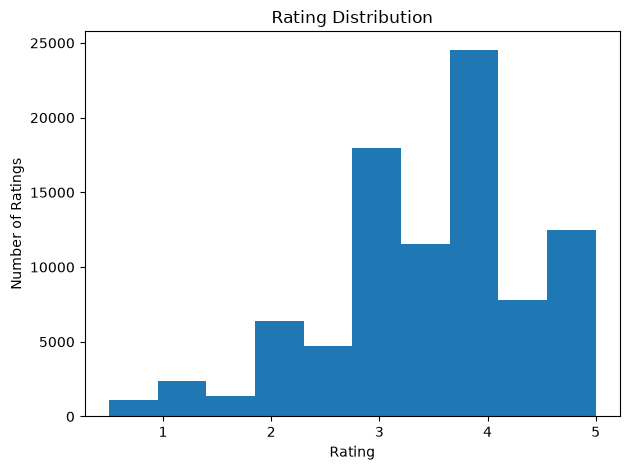

In [25]:
rating_distribution = ratings_df["rating"]

plt.hist(rating_distribution)
plt.title("Rating Distribution")
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

#### 4. Show top 5 movies after the average rating

In [26]:
movie_avg = ratings_df.groupby('movieId')['rating'].mean().reset_index()

movie_avg = movie_avg.merge(movies_df, on='movieId')

global_avg = movie_avg['rating'].mean()

top_5 = (
    movie_avg[movie_avg['rating'] > global_avg]
    .sort_values('rating', ascending=False)
    .head(5)
)

print(top_5[['title', 'rating']])

                                                  title    rating
2338                     Trial, The (Procès, Le) (1962)  4.900000
3641   Three Billboards Outside Ebbing, Missouri (2017)  4.750000
2674         Memories of Murder (Salinui chueok) (2003)  4.700000
1129  Swept Away (Travolti da un insolito destino ne...  4.666667
1973                                       Yi Yi (2000)  4.600000


#### 5. Genre count histogram

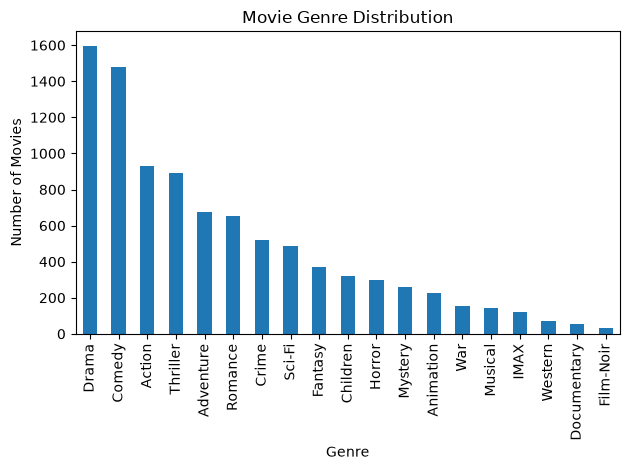

In [18]:
genres_series = movies_df['genres'].str.split('|').explode()
genres_series = genres_series[genres_series != '(no genres listed)']

genre_counts = genres_series.value_counts()
genre_counts.plot(kind='bar')

plt.title('Movie Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()